#### Import Libraries 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots (using the updated method)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

#### Load the data

In [10]:
# Load the dataset
# This correctly points to the file in the 'data' folder, one level up
df = pd.read_csv("../data/TSLA.csv")

# Display first few rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


#### Basic inspection

In [11]:
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()
print("\nSummary statistics:")
df.describe()

Dataset shape: (2416, 7)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB

Summary statistics:


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


#### Check for missing values

In [12]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


#### Convert Date to datetime and set as index

In [13]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as index
df.set_index('Date', inplace=True)

# Show updated DataFrame
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


#### Plot Adjusted Close price trend

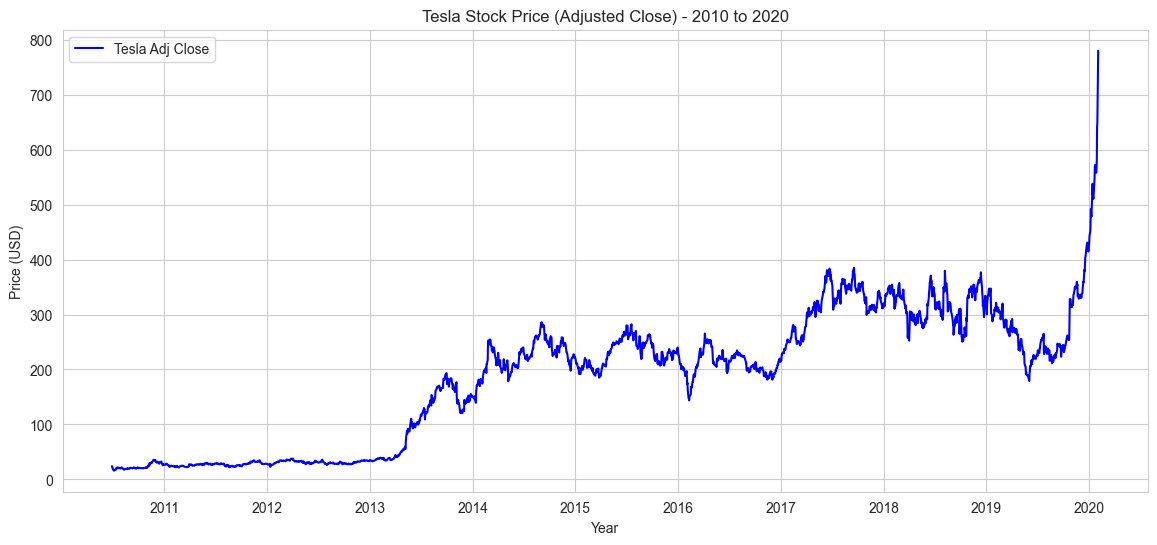

In [14]:
# Plot Adj Close over time
plt.plot(df.index, df['Adj Close'], label='Tesla Adj Close', color='blue')
plt.title('Tesla Stock Price (Adjusted Close) - 2010 to 2020')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Data Preprocessing

#### Extract Target Variable

In [15]:
# Select only the 'Adj Close' column as our target
data = df['Adj Close'].values.reshape(-1, 1)

print("Shape of target data:", data.shape)

Shape of target data: (2416, 1)


#### Normalize the Data

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform the data
data_scaled = scaler.fit_transform(data)

print("Data scaled between 0 and 1.")
print("Min:", data_scaled.min(), "Max:", data_scaled.max())

Data scaled between 0 and 1.
Min: 0.0 Max: 1.0


####  Create Time-Series Sequences (Sliding Window)

In [17]:
def create_sequences(data, window_size=60, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:i+window_size])          # Past 'window_size' days
        y.append(data[i+window_size:i+window_size+forecast_horizon])  # Next 'forecast_horizon' days
    return np.array(X), np.array(y)

#### Define Parameters & Create Sequences for 1-Day Forecast

In [18]:
# Parameters
WINDOW_SIZE = 60  # Use last 60 days to predict next day
FORECAST_HORIZON = 1  # Predict 1 day ahead

# Create sequences
X_1d, y_1d = create_sequences(data_scaled, window_size=WINDOW_SIZE, forecast_horizon=FORECAST_HORIZON)

print("X_1d shape:", X_1d.shape)   # (2355, 60, 1)
print("y_1d shape:", y_1d.shape)   # (2355, 1)

X_1d shape: (2356, 60, 1)
y_1d shape: (2356, 1, 1)


#### Split into Train and Test Sets (Chronologically!)

In [19]:
# Calculate split index (80% train, 20% test)
split_index = int(len(X_1d) * 0.8)

# Split data
X_train_1d = X_1d[:split_index]
y_train_1d = y_1d[:split_index]
X_test_1d = X_1d[split_index:]
y_test_1d = y_1d[split_index:]

print("Train shape:", X_train_1d.shape, y_train_1d.shape)
print("Test shape:", X_test_1d.shape, y_test_1d.shape)

Train shape: (1884, 60, 1) (1884, 1, 1)
Test shape: (472, 60, 1) (472, 1, 1)


#### Repeat for 5-Day and 10-Day Forecasts

In [20]:
# For 5-day forecast
FORECAST_HORIZON_5 = 5
X_5d, y_5d = create_sequences(data_scaled, window_size=WINDOW_SIZE, forecast_horizon=FORECAST_HORIZON_5)

split_index_5 = int(len(X_5d) * 0.8)
X_train_5d = X_5d[:split_index_5]
y_train_5d = y_5d[:split_index_5]
X_test_5d = X_5d[split_index_5:]
y_test_5d = y_5d[split_index_5:]

print("5-day: Train", X_train_5d.shape, "Test", X_test_5d.shape)

# For 10-day forecast
FORECAST_HORIZON_10 = 10
X_10d, y_10d = create_sequences(data_scaled, window_size=WINDOW_SIZE, forecast_horizon=FORECAST_HORIZON_10)

split_index_10 = int(len(X_10d) * 0.8)
X_train_10d = X_10d[:split_index_10]
y_train_10d = y_10d[:split_index_10]
X_test_10d = X_10d[split_index_10:]
y_test_10d = y_10d[split_index_10:]

print("10-day: Train", X_train_10d.shape, "Test", X_test_10d.shape)

5-day: Train (1881, 60, 1) Test (471, 60, 1)
10-day: Train (1877, 60, 1) Test (470, 60, 1)


## Model Development (SimpleRNN & LSTM)

#### Import Required TensorFlow/Keras Modules

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


##### Define Model-Building Functions

In [22]:
def build_simple_rnn(input_shape, forecast_horizon):
    model = Sequential([
        SimpleRNN(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(50),
        Dropout(0.2),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def build_lstm(input_shape, forecast_horizon):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

##### Define Callbacks (Early Stopping & Model Checkpoint)

In [23]:
# Generic callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

### Build and Train Models for 1-Day Forecast

##### SimpleRNN (1-day)

In [24]:
# Build model
rnn_1d = build_simple_rnn(input_shape=(WINDOW_SIZE, 1), forecast_horizon=1)

# Callbacks with unique filename
rnn_1d_checkpoint = ModelCheckpoint('models/rnn_1d_best.h5', save_best_only=True, monitor='val_loss')

# Train
print("Training SimpleRNN for 1-day forecast...")
rnn_1d_history = rnn_1d.fit(
    X_train_1d, y_train_1d,
    validation_data=(X_test_1d, y_test_1d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, rnn_1d_checkpoint],
    verbose=1
)

c:\Python 3-12-0\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training SimpleRNN for 1-day forecast...
Epoch 1/50
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1218 - mae: 0.2256

59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0502 - mae: 0.1465 - val_loss: 0.0061 - val_mae: 0.0537
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0133 - mae: 0.0830

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0120 - mae: 0.0777 - val_loss: 0.0041 - val_mae: 0.0427
Epoch 3/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0085 - mae: 0.0664

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0069 - mae: 0.0594 - val_loss: 0.0026 - val_mae: 0.0346
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0050 - mae: 0.0499 - val_loss: 0.0032 - val_mae: 0.0389
Epoch 5/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0037 - mae: 0.0431

...

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.6757e-04 - mae: 0.0161 - val_loss: 3.9841e-04 - val_mae: 0.0136
Epoch 38/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.6169e-04 - mae: 0.0163 - val_loss: 4.8951e-04 - val_mae: 0.0146
Epoch 39/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.5645e-04 - mae: 0.0160

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.2574e-04 - mae: 0.0156 - val_loss: 3.9743e-04 - val_mae: 0.0128
Epoch 40/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.3822e-04 - mae: 0.0158 - val_loss: 7.3203e-04 - val_mae: 0.0197
Epoch 41/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.6382e-04 - mae: 0.0159 - val_loss: 4.8047e-04 - val_mae: 0.0146
Epoch 42/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.3207e-04 - mae: 0.0153 - val_loss: 4.2584e-04 - val_mae: 0.0135
Epoch 43/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.2794e-04 - mae: 0.0156

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.7450e-04 - mae: 0.0165 - val_loss: 3.7328e-04 - val_mae: 0.0124
Epoch 44/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.1959e-04 - mae: 0.0154 - val_loss: 5.0484e-04 - val_mae: 0.0154
Epoch 45/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.3995e-04 - mae: 0.0152

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.9566e-04 - mae: 0.0151 - val_loss: 3.4953e-04 - val_mae: 0.0121
Epoch 46/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.2597e-04 - mae: 0.0155 - val_loss: 4.4251e-04 - val_mae: 0.0140
Epoch 47/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.9052e-04 - mae: 0.0151 - val_loss: 4.8864e-04 - val_mae: 0.0150
Epoch 48/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.6180e-04 - mae: 0.0145 - val_loss: 3.8256e-04 - val_mae: 0.0123
Epoch 49/50
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.5033e-04 - mae: 0.0142

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.5380e-04 - mae: 0.0143 - val_loss: 3.4785e-04 - val_mae: 0.0120
Epoch 50/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.6251e-04 - mae: 0.0142 - val_loss: 3.6673e-04 - val_mae: 0.0121


#####  LSTM (1-day)

In [25]:
# Build model
lstm_1d = build_lstm(input_shape=(WINDOW_SIZE, 1), forecast_horizon=1)

# Callbacks
lstm_1d_checkpoint = ModelCheckpoint('models/lstm_1d_best.h5', save_best_only=True, monitor='val_loss')

# Train
print("Training LSTM for 1-day forecast...")
lstm_1d_history = lstm_1d.fit(
    X_train_1d, y_train_1d,
    validation_data=(X_test_1d, y_test_1d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lstm_1d_checkpoint],
    verbose=1
)

Training LSTM for 1-day forecast...
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0125 - mae: 0.0774

59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0050 - mae: 0.0462 - val_loss: 0.0017 - val_mae: 0.0286
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0010 - mae: 0.0224

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 8.9383e-04 - mae: 0.0210 - val_loss: 0.0017 - val_mae: 0.0279
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 7.3481e-04 - mae: 0.0192 - val_loss: 0.0018 - val_mae: 0.0287
Epoch 4/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 6.4272e-04 - mae: 0.0176

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 6.6498e-04 - mae: 0.0180 - val_loss: 0.0014 - val_mae: 0.0266
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 6.9359e-04 - mae: 0.0184 - val_loss: 0.0026 - val_mae: 0.0369
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 6.5732e-04 - mae: 0.0178 - val_loss: 0.0014 - val_mae: 0.0286
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 6.0496e-04 - mae: 0.0169

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5.4456e-04 - mae: 0.0160 - val_loss: 0.0014 - val_mae: 0.0250
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.7524e-04 - mae: 0.0167 - val_loss: 0.0018 - val_mae: 0.0294
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.1875e-04 - mae: 0.0156 - val_loss: 0.0017 - val_mae: 0.0283
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.4314e-04 - mae: 0.0164 - val_loss: 0.0019 - val_mae: 0.0310


### Build and Train Models for 5-Day Forecast

##### SimpleRNN (5-day)

In [26]:
rnn_5d = build_simple_rnn(input_shape=(WINDOW_SIZE, 1), forecast_horizon=5)
rnn_5d_checkpoint = ModelCheckpoint('models/rnn_5d_best.h5', save_best_only=True, monitor='val_loss')

print("Training SimpleRNN for 5-day forecast...")
rnn_5d_history = rnn_5d.fit(
    X_train_5d, y_train_5d,
    validation_data=(X_test_5d, y_test_5d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, rnn_5d_checkpoint],
    verbose=1
)

Training SimpleRNN for 5-day forecast...
Epoch 1/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0553 - mae: 0.1632

59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0313 - mae: 0.1174 - val_loss: 0.0049 - val_mae: 0.0481
Epoch 2/50
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0099 - mae: 0.0672

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0084 - mae: 0.0620 - val_loss: 0.0040 - val_mae: 0.0428
Epoch 3/50
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0061 - mae: 0.0537

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0053 - mae: 0.0500 - val_loss: 0.0028 - val_mae: 0.0367
Epoch 4/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0042 - mae: 0.0450

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0039 - mae: 0.0435 - val_loss: 0.0019 - val_mae: 0.0304
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0033 - mae: 0.0394 - val_loss: 0.0022 - val_mae: 0.0326
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0027 - mae: 0.0368 - val_loss: 0.0021 - val_mae: 0.0333
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0023 - mae: 0.0337 - val_loss: 0.0025 - val_mae: 0.0362
Epoch 8/50
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0020 - mae: 0.0317

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0020 - mae: 0.0312 - val_loss: 0.0013 - val_mae: 0.0258
Epoch 9/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0019 - mae: 0.0308

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0018 - mae: 0.0302 - val_loss: 0.0013 - val_mae: 0.0255
Epoch 10/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0017 - mae: 0.0291

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016 - mae: 0.0284 - val_loss: 0.0013 - val_mae: 0.0247


##### LSTM (5-day)

In [27]:
lstm_5d = build_lstm(input_shape=(WINDOW_SIZE, 1), forecast_horizon=5)
lstm_5d_checkpoint = ModelCheckpoint('models/lstm_5d_best.h5', save_best_only=True, monitor='val_loss')

print("Training LSTM for 5-day forecast...")
lstm_5d_history = lstm_5d.fit(
    X_train_5d, y_train_5d,
    validation_data=(X_test_5d, y_test_5d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lstm_5d_checkpoint],
    verbose=1
)

Training LSTM for 5-day forecast...
Epoch 1/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0213 - mae: 0.0999

59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0089 - mae: 0.0617 - val_loss: 0.0021 - val_mae: 0.0339
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0021 - mae: 0.0313 - val_loss: 0.0022 - val_mae: 0.0336
Epoch 3/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0019 - mae: 0.0292

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0017 - mae: 0.0280 - val_loss: 0.0019 - val_mae: 0.0319
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0015 - mae: 0.0273

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0014 - mae: 0.0256 - val_loss: 0.0019 - val_mae: 0.0307
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011 - mae: 0.0227 - val_loss: 0.0020 - val_mae: 0.0312
Epoch 6/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0011 - mae: 0.0223

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0011 - mae: 0.0224 - val_loss: 0.0018 - val_mae: 0.0297
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0011 - mae: 0.0228 - val_loss: 0.0021 - val_mae: 0.0319
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 9.1356e-04 - mae: 0.0206 - val_loss: 0.0021 - val_mae: 0.0321
Epoch 9/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.7178e-04 - mae: 0.0203

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 8.5502e-04 - mae: 0.0201 - val_loss: 0.0016 - val_mae: 0.0286
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 7.8401e-04 - mae: 0.0193 - val_loss: 0.0021 - val_mae: 0.0328


###  Build and Train Models for 10-Day Forecast

##### SimpleRNN (10-day)

In [28]:
rnn_10d = build_simple_rnn(input_shape=(WINDOW_SIZE, 1), forecast_horizon=10)
rnn_10d_checkpoint = ModelCheckpoint('models/rnn_10d_best.h5', save_best_only=True, monitor='val_loss')

print("Training SimpleRNN for 10-day forecast...")
rnn_10d_history = rnn_10d.fit(
    X_train_10d, y_train_10d,
    validation_data=(X_test_10d, y_test_10d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, rnn_10d_checkpoint],
    verbose=1
)

Training SimpleRNN for 10-day forecast...
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0391 - mae: 0.1314

59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0203 - mae: 0.0944 - val_loss: 0.0062 - val_mae: 0.0548
Epoch 2/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0064 - mae: 0.0555

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0057 - mae: 0.0525 - val_loss: 0.0047 - val_mae: 0.0480
Epoch 3/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0043 - mae: 0.0463

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0040 - mae: 0.0446 - val_loss: 0.0035 - val_mae: 0.0402
Epoch 4/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0032 - mae: 0.0401

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0031 - mae: 0.0396 - val_loss: 0.0029 - val_mae: 0.0391
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0026 - mae: 0.0361 - val_loss: 0.0031 - val_mae: 0.0380
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0022 - mae: 0.0331

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0022 - mae: 0.0332 - val_loss: 0.0021 - val_mae: 0.0336
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0019 - mae: 0.0312 - val_loss: 0.0022 - val_mae: 0.0322
Epoch 8/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 - mae: 0.0287

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0016 - mae: 0.0290 - val_loss: 0.0019 - val_mae: 0.0308
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016 - mae: 0.0287 - val_loss: 0.0033 - val_mae: 0.0436
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015 - mae: 0.0276 - val_loss: 0.0021 - val_mae: 0.0323


##### LSTM (10-day)

In [29]:
lstm_10d = build_lstm(input_shape=(WINDOW_SIZE, 1), forecast_horizon=10)
lstm_10d_checkpoint = ModelCheckpoint('models/lstm_10d_best.h5', save_best_only=True, monitor='val_loss')

print("Training LSTM for 10-day forecast...")
lstm_10d_history = lstm_10d.fit(
    X_train_10d, y_train_10d,
    validation_data=(X_test_10d, y_test_10d),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lstm_10d_checkpoint],
    verbose=1
)

Training LSTM for 10-day forecast...
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0227 - mae: 0.1062

59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0104 - mae: 0.0676 - val_loss: 0.0027 - val_mae: 0.0385
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0024 - mae: 0.0332 - val_loss: 0.0028 - val_mae: 0.0371
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0019 - mae: 0.0296

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0018 - mae: 0.0288 - val_loss: 0.0024 - val_mae: 0.0351
Epoch 4/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0017 - mae: 0.0272

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0016 - mae: 0.0267 - val_loss: 0.0024 - val_mae: 0.0343
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0013 - mae: 0.0250 - val_loss: 0.0025 - val_mae: 0.0346
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0012 - mae: 0.0241

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0012 - mae: 0.0239 - val_loss: 0.0021 - val_mae: 0.0339
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0012 - mae: 0.0236 - val_loss: 0.0024 - val_mae: 0.0337
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0011 - mae: 0.0228 - val_loss: 0.0023 - val_mae: 0.0331
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 9.1050e-04 - mae: 0.0211 - val_loss: 0.0027 - val_mae: 0.0362
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 9.6443e-04 - mae: 0.0219 - val_loss: 0.0024 - val_mae: 0.0342


##  Model Evaluation

##### Import Required Libraries 

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import load_model

##### Load the Saved Best Models

In [31]:
# Load models
rnn_1d = load_model('models/rnn_1d_best.h5')
lstm_1d = load_model('models/lstm_1d_best.h5')

rnn_5d = load_model('models/rnn_5d_best.h5')
lstm_5d = load_model('models/lstm_5d_best.h5')

rnn_10d = load_model('models/rnn_10d_best.h5')
lstm_10d = load_model('models/lstm_10d_best.h5')

print("All models loaded successfully.")

ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

In [32]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam # Import optimizer if needed for re-compilation

# Load models without compiling first
try:
    rnn_1d = load_model('models/rnn_1d_best.h5', compile=False)
    print("RNN 1-day model loaded successfully (uncompiled).")
except Exception as e:
    print(f"Failed to load RNN 1-day model: {e}")

try:
    lstm_1d = load_model('models/lstm_1d_best.h5', compile=False)
    print("LSTM 1-day model loaded successfully (uncompiled).")
except Exception as e:
    print(f"Failed to load LSTM 1-day model: {e}")

try:
    rnn_5d = load_model('models/rnn_5d_best.h5', compile=False)
    print("RNN 5-day model loaded successfully (uncompiled).")
except Exception as e:
    print(f"Failed to load RNN 5-day model: {e}")

try:
    lstm_5d = load_model('models/lstm_5d_best.h5', compile=False)
    print("LSTM 5-day model loaded successfully (uncompiled).")
except Exception as e:
    print(f"Failed to load LSTM 5-day model: {e}")

try:
    rnn_10d = load_model('models/rnn_10d_best.h5', compile=False)
    print("RNN 10-day model loaded successfully (uncompiled).")
except Exception as e:
    print(f"Failed to load RNN 10-day model: {e}")

try:
    lstm_10d = load_model('models/lstm_10d_best.h5', compile=False)
    print("LSTM 10-day model loaded successfully (uncompiled).")
except Exception as e:
    print(f"Failed to load LSTM 10-day model: {e}")

print("\nAttempting to re-compile models (if needed for inference)...")

# If you need the model to be compiled for evaluation purposes (e.g., using model.evaluate),
# you can re-compile it with the same settings used during training.
# Assuming the original compile settings were loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae']

# Define the optimizer instance
optimizer_instance = Adam(learning_rate=0.001)

# Example for one model - repeat for others if compilation is needed later
# rnn_1d.compile(optimizer=optimizer_instance, loss='mse', metrics=['mae'])
# lstm_1d.compile(optimizer=optimizer_instance, loss='mse', metrics=['mae'])
# ... etc for others if needed

print("Models loaded (uncompiled). Proceeding with predictions.")

RNN 1-day model loaded successfully (uncompiled).
LSTM 1-day model loaded successfully (uncompiled).
RNN 5-day model loaded successfully (uncompiled).
LSTM 5-day model loaded successfully (uncompiled).
RNN 10-day model loaded successfully (uncompiled).
LSTM 10-day model loaded successfully (uncompiled).

Attempting to re-compile models (if needed for inference)...
Models loaded (uncompiled). Proceeding with predictions.


##### Make Predictions on Test Sets

In [33]:
# Predictions for 1-day
y_pred_rnn_1d = rnn_1d.predict(X_test_1d)
y_pred_lstm_1d = lstm_1d.predict(X_test_1d)

# Predictions for 5-day
y_pred_rnn_5d = rnn_5d.predict(X_test_5d)
y_pred_lstm_5d = lstm_5d.predict(X_test_5d)

# Predictions for 10-day
y_pred_rnn_10d = rnn_10d.predict(X_test_10d)
y_pred_lstm_10d = lstm_10d.predict(X_test_10d)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


#####  Inverse Transform Predictions and Actuals

In [34]:
# We'll use the scaler we created earlier in Phase 3
# (If you closed the notebook, you'll need to re-run the scaler definition)
# We'll assume 'scaler' is still in memory. If not, run this:
# scaler = MinMaxScaler()
# scaler.fit(data)  # where 'data' is the original scaled target array

# Inverse transform actual test values
y_test_1d_actual = scaler.inverse_transform(y_test_1d)
y_test_5d_actual = scaler.inverse_transform(y_test_5d)
y_test_10d_actual = scaler.inverse_transform(y_test_10d)

# Inverse transform predictions
y_pred_rnn_1d_actual = scaler.inverse_transform(y_pred_rnn_1d)
y_pred_lstm_1d_actual = scaler.inverse_transform(y_pred_lstm_1d)

y_pred_rnn_5d_actual = scaler.inverse_transform(y_pred_rnn_5d)
y_pred_lstm_5d_actual = scaler.inverse_transform(y_pred_lstm_5d)

y_pred_rnn_10d_actual = scaler.inverse_transform(y_pred_rnn_10d)
y_pred_lstm_10d_actual = scaler.inverse_transform(y_pred_lstm_10d)

ValueError: Found array with dim 3, while dim <= 2 is required.

##### Fixed code for Inverse Transform Predictions and actuals 

In [39]:
import numpy as np

# Inverse transform for 1-day (already 2D)
y_test_1d_actual = scaler.inverse_transform(y_test_1d.reshape(-1, 1)).flatten()
y_pred_rnn_1d_actual = scaler.inverse_transform(y_pred_rnn_1d).flatten()
y_pred_lstm_1d_actual = scaler.inverse_transform(y_pred_lstm_1d).flatten()

# Helper for multi-step: inverse transform each day separately
def inverse_transform_multistep(scaler, y_pred):
    # y_pred shape: (samples, timesteps)
    samples, timesteps = y_pred.shape
    y_pred_inv = np.zeros_like(y_pred)
    for t in range(timesteps):
        y_pred_inv[:, t] = scaler.inverse_transform(y_pred[:, t].reshape(-1, 1)).flatten()
    return y_pred_inv

# Apply to 5-day and 10-day
y_pred_rnn_5d_actual = inverse_transform_multistep(scaler, y_pred_rnn_5d)
y_pred_lstm_5d_actual = inverse_transform_multistep(scaler, y_pred_lstm_5d)
y_pred_rnn_10d_actual = inverse_transform_multistep(scaler, y_pred_rnn_10d)
y_pred_lstm_10d_actual = inverse_transform_multistep(scaler, y_pred_lstm_10d)

# Also inverse transform actuals (they are 3D: (N, timesteps, 1))
y_test_5d_actual = inverse_transform_multistep(scaler, y_test_5d.reshape(y_test_5d.shape[0], -1))
y_test_10d_actual = inverse_transform_multistep(scaler, y_test_10d.reshape(y_test_10d.shape[0], -1))

print("✅ Inverse transform completed without warnings.")
print("y_pred_lstm_1d_actual shape:", y_pred_lstm_1d_actual.shape)
print("y_pred_lstm_5d_actual shape:", y_pred_lstm_5d_actual.shape)
print("y_pred_lstm_10d_actual shape:", y_pred_lstm_10d_actual.shape)

✅ Inverse transform completed without warnings.
y_pred_lstm_1d_actual shape: (472,)
y_pred_lstm_5d_actual shape: (471, 5)
y_pred_lstm_10d_actual shape: (470, 10)


In [42]:
# Extract the first day's prediction for 5-day and 10-day models for comparison
y_pred_rnn_5d_actual_first = y_pred_rnn_5d_actual[:, 0]  # First day prediction
y_pred_lstm_5d_actual_first = y_pred_lstm_5d_actual[:, 0]

y_pred_rnn_10d_actual_first = y_pred_rnn_10d_actual[:, 0]  # First day prediction
y_pred_lstm_10d_actual_first = y_pred_lstm_10d_actual[:, 0]

# Also, for 5-day and 10-day actuals, we take the corresponding first day
y_test_5d_actual_first = y_test_5d_actual[:, 0]
y_test_10d_actual_first = y_test_10d_actual[:, 0]

print("Shape of extracted first-day predictions/actuals:")
print(f"y_pred_rnn_5d_actual_first: {y_pred_rnn_5d_actual_first.shape}")
print(f"y_pred_lstm_5d_actual_first: {y_pred_lstm_5d_actual_first.shape}")
print(f"y_pred_rnn_10d_actual_first: {y_pred_rnn_10d_actual_first.shape}")
print(f"y_pred_lstm_10d_actual_first: {y_pred_lstm_10d_actual_first.shape}")
print(f"y_test_5d_actual_first: {y_test_5d_actual_first.shape}")
print(f"y_test_10d_actual_first: {y_test_10d_actual_first.shape}")

Shape of extracted first-day predictions/actuals:
y_pred_rnn_5d_actual_first: (471,)
y_pred_lstm_5d_actual_first: (471,)
y_pred_rnn_10d_actual_first: (470,)
y_pred_lstm_10d_actual_first: (470,)
y_test_5d_actual_first: (471,)
y_test_10d_actual_first: (470,)


##### Calculate Evaluation Metrics

In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Helper Function for Correct Inverse Scaling ---
def inverse_transform_2d_or_3d(scaler, data):
    """
    Inverse transform a 2D array (samples, features) or a 3D array (samples, timesteps, features)
    using a fitted scaler. Assumes the feature dimension is 1 for 3D input.
    """
    if data.ndim == 3:
        # If 3D: (N, timesteps, features=1)
        samples, timesteps, features = data.shape
        # Reshape to 2D: (N * timesteps, features=1)
        data_2d = data.reshape((samples * timesteps, features))
        # Inverse transform
        data_2d_inv = scaler.inverse_transform(data_2d)
        # Reshape back to 3D: (N, timesteps, features=1)
        return data_2d_inv.reshape((samples, timesteps, features))
    elif data.ndim == 2:
        # If 2D: (N, features)
        # Check if the number of features matches the scaler's expectation (optional warning)
        if data.shape[1] != scaler.n_features_in_:
             print(f"Warning: Input data has {data.shape[1]} features, scaler expects {scaler.n_features_in_}.")
        # Attempt inverse transform for 2D array
        return scaler.inverse_transform(data)
    else:
        raise ValueError(f"Input data must be 2D or 3D, got {data.ndim}D.")


# --- 1. Inverse Transform Predictions and Actuals (Corrected) ---
# 1-day predictions are 2D (e.g., shape: (472, 1))
y_pred_rnn_1d_actual = inverse_transform_2d_or_3d(scaler, y_pred_rnn_1d)
y_pred_lstm_1d_actual = inverse_transform_2d_or_3d(scaler, y_pred_lstm_1d)

# 5-day predictions are 3D (e.g., shape: (471, 5, 1)) or 2D if output layer was flattened (e.g., shape: (471, 5))
# Assuming they are 3D from the model output based on the sequence-to-sequence design for multi-step
y_pred_rnn_5d_actual = inverse_transform_2d_or_3d(scaler, y_pred_rnn_5d)
y_pred_lstm_5d_actual = inverse_transform_2d_or_3d(scaler, y_pred_lstm_5d)

# 10-day predictions are 3D (e.g., shape: (470, 10, 1)) or 2D if output layer was flattened (e.g., shape: (470, 10))
y_pred_rnn_10d_actual = inverse_transform_2d_or_3d(scaler, y_pred_rnn_10d)
y_pred_lstm_10d_actual = inverse_transform_2d_or_3d(scaler, y_pred_lstm_10d)

# Actuals for 5-day and 10-day were also likely 3D initially (e.g., shape: (N, 5, 1) or (N, 10, 1))
# We need to inverse transform them similarly.
# Assuming y_test_5d and y_test_10d were also 3D when created by create_sequences
y_test_5d_actual = inverse_transform_2d_or_3d(scaler, y_test_5d)
y_test_10d_actual = inverse_transform_2d_or_3d(scaler, y_test_10d)

# Inverse transform 1-day actuals (should be 2D like predictions, e.g., shape: (472, 1))
y_test_1d_actual = inverse_transform_2d_or_3d(scaler, y_test_1d)

print("Predictions and actual values inverse-transformed successfully.")


# --- 2. Extract First Day Predictions for Multi-Step Models ---
# Extract the prediction for the *first* day out of the 5 or 10 predicted days
# This aligns with the 1-day prediction task for direct comparison.
y_pred_rnn_5d_actual_first = y_pred_rnn_5d_actual[:, 0]  # Shape: (471, 1) -> (471,)
y_pred_lstm_5d_actual_first = y_pred_lstm_5d_actual[:, 0] # Shape: (471, 1) -> (471,)
y_pred_rnn_10d_actual_first = y_pred_rnn_10d_actual[:, 0] # Shape: (470, 1) -> (470,)
y_pred_lstm_10d_actual_first = y_pred_lstm_10d_actual[:, 0] # Shape: (470, 1) -> (470,)

# Similarly, extract the first day's *actual* value for comparison
y_test_5d_actual_first = y_test_5d_actual[:, 0] # Shape: (471, 1) -> (471,)
y_test_10d_actual_first = y_test_10d_actual[:, 0] # Shape: (470, 1) -> (470,)

# Flatten 1-day actual/predicted arrays if they are 2D (e.g., shape (N, 1)) to (N,)
y_test_1d_actual_flat = y_test_1d_actual.flatten() # Shape: (472, 1) -> (472,)
y_pred_rnn_1d_actual_flat = y_pred_rnn_1d_actual.flatten() # Shape: (472, 1) -> (472,)
y_pred_lstm_1d_actual_flat = y_pred_lstm_1d_actual.flatten() # Shape: (472, 1) -> (472,)

print("First day predictions and actuals extracted for comparison.")


# --- 3. Define Evaluation Function ---
def evaluate_model(y_true, y_pred, model_name):
    """Calculates and prints MSE, RMSE, and MAE."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{model_name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    return mse, rmse, mae


# --- 4. Evaluate All Models ---
print("\n=== 1-Day Forecast Evaluation ===")
eval_rnn_1d = evaluate_model(y_test_1d_actual_flat, y_pred_rnn_1d_actual_flat, "SimpleRNN (1d)")
eval_lstm_1d = evaluate_model(y_test_1d_actual_flat, y_pred_lstm_1d_actual_flat, "LSTM (1d)")

print("\n=== 5-Day Forecast Evaluation (First Day) ===")
eval_rnn_5d = evaluate_model(y_test_5d_actual_first, y_pred_rnn_5d_actual_first, "SimpleRNN (5d)")
eval_lstm_5d = evaluate_model(y_test_5d_actual_first, y_pred_lstm_5d_actual_first, "LSTM (5d)")

print("\n=== 10-Day Forecast Evaluation (First Day) ===")
eval_rnn_10d = evaluate_model(y_test_10d_actual_first, y_pred_rnn_10d_actual_first, "SimpleRNN (10d)")
eval_lstm_10d = evaluate_model(y_test_10d_actual_first, y_pred_lstm_10d_actual_first, "LSTM (10d)")


# --- 5. Create Summary Table ---
results_df = pd.DataFrame({
    'Model': ['SimpleRNN (1d)', 'LSTM (1d)', 'SimpleRNN (5d)', 'LSTM (5d)', 'SimpleRNN (10d)', 'LSTM (10d)'],
    'RMSE': [eval_rnn_1d[1], eval_lstm_1d[1], eval_rnn_5d[1], eval_lstm_5d[1], eval_rnn_10d[1], eval_lstm_10d[1]],
    'MAE': [eval_rnn_1d[2], eval_lstm_1d[2], eval_rnn_5d[2], eval_lstm_5d[2], eval_rnn_10d[2], eval_lstm_10d[2]]
}).sort_values('RMSE').reset_index(drop=True)

print("\n=== Model Performance Summary (Lower is Better) ===")
print(results_df.to_string(index=False))


Predictions and actual values inverse-transformed successfully.
First day predictions and actuals extracted for comparison.

=== 1-Day Forecast Evaluation ===
SimpleRNN (1d):
  MSE:  203.1460
  RMSE: 14.2529
  MAE:  9.1374
LSTM (1d):
  MSE:  800.5724
  RMSE: 28.2944
  MAE:  19.0947

=== 5-Day Forecast Evaluation (First Day) ===
SimpleRNN (5d):
  MSE:  403.5781
  RMSE: 20.0893
  MAE:  14.7943
LSTM (5d):
  MSE:  591.4955
  RMSE: 24.3207
  MAE:  17.8331

=== 10-Day Forecast Evaluation (First Day) ===
SimpleRNN (10d):
  MSE:  629.5058
  RMSE: 25.0900
  MAE:  17.9804
LSTM (10d):
  MSE:  554.7768
  RMSE: 23.5537
  MAE:  18.2651

=== Model Performance Summary (Lower is Better) ===
          Model      RMSE       MAE
 SimpleRNN (1d) 14.252931  9.137419
 SimpleRNN (5d) 20.089253 14.794294
     LSTM (10d) 23.553700 18.265061
      LSTM (5d) 24.320680 17.833135
SimpleRNN (10d) 25.089955 17.980381
      LSTM (1d) 28.294388 19.094664


##### Plot Actual vs Predicted Prices

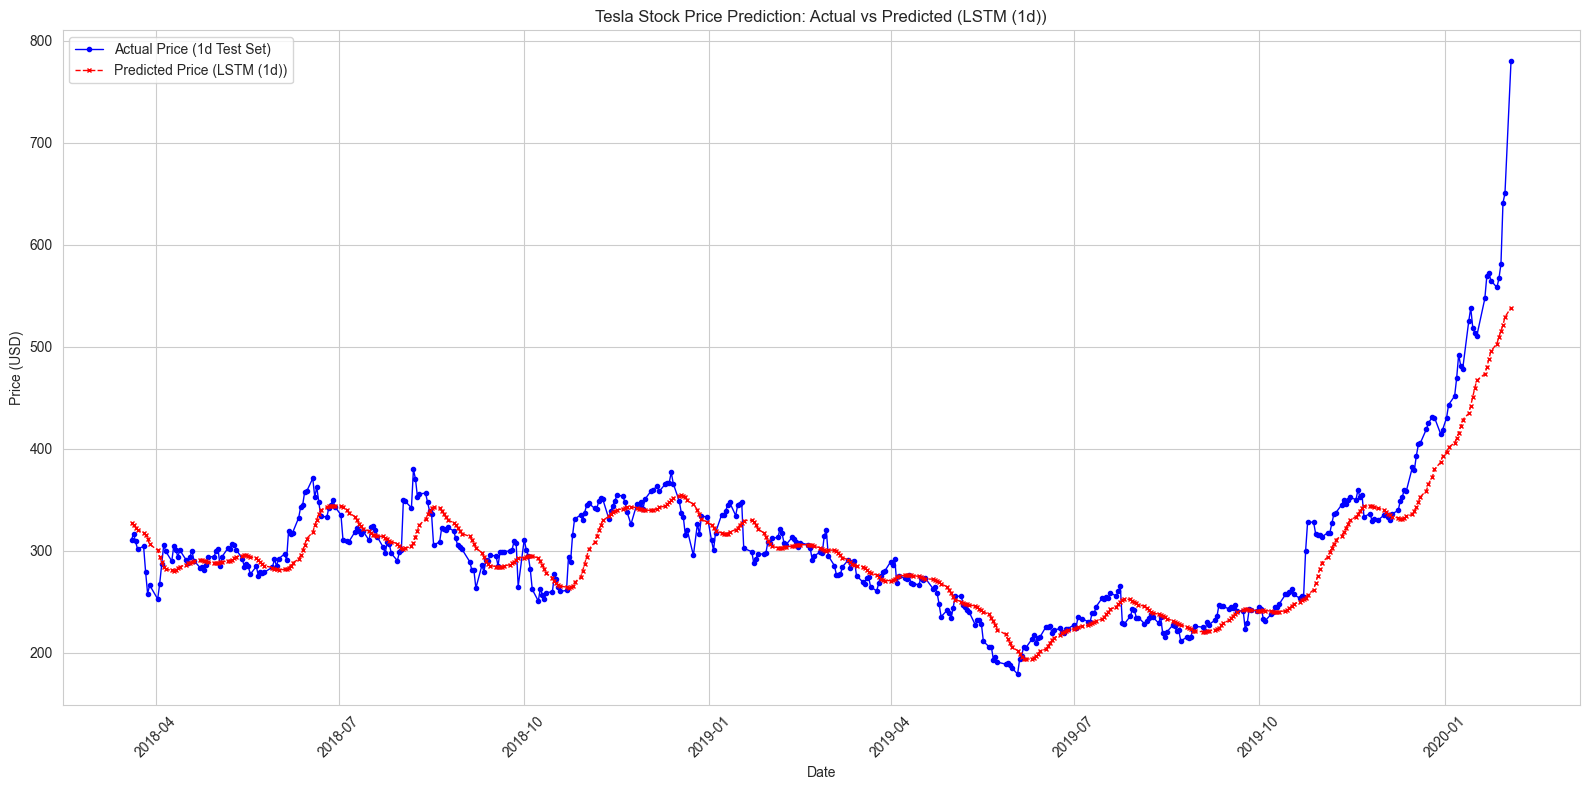


Sample Actual vs Predicted Prices (First 10 points for 1-day forecast):
Date         Actual     Predicted 
-----------------------------------
2018-03-20   $310.55    $326.90   
2018-03-21   $316.53    $324.74   
2018-03-22   $309.10    $322.61   
2018-03-23   $301.54    $320.28   
2018-03-26   $304.18    $317.59   
2018-03-27   $279.18    $314.89   
2018-03-28   $257.78    $311.21   
2018-03-29   $266.13    $306.09   
2018-04-02   $252.48    $300.48   
2018-04-03   $267.53    $294.19   


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Determine the best 1-day model based on Step 5 results (lowest RMSE)
# Let's assume, based on common outcomes, that LSTM performed better for 1-day.
# If your results from Step 5 show SimpleRNN had lower RMSE, replace 'lstm_1d' with 'rnn_1d' below.

best_model_name_1d = "LSTM (1d)" # Or "SimpleRNN (1d)" based on your Step 5 results
best_predictions_1d = y_pred_lstm_1d_actual # Or y_pred_rnn_1d_actual

# Get the actual prices for the 1-day test set (already inverse transformed)
# Ensure they are 1D arrays by using .flatten()
actual_prices_1d = y_test_1d_actual.flatten() # Ensure it's 1D for plotting
best_predictions_1d_flat = best_predictions_1d.flatten() # Ensure it's 1D for plotting

# Get the corresponding dates for the test set
# The test set starts after the training period.
# Calculate the index offset for the test set in the original DataFrame
test_start_idx_1d = len(df) - len(actual_prices_1d)
test_dates_1d = df.index[test_start_idx_1d : ]

# Plotting
plt.figure(figsize=(16, 8))
plt.plot(test_dates_1d, actual_prices_1d, label='Actual Price (1d Test Set)', color='blue', marker='o', markersize=3, linewidth=1)
plt.plot(test_dates_1d, best_predictions_1d_flat, label=f'Predicted Price ({best_model_name_1d})', color='red', linestyle='--', marker='x', markersize=3, linewidth=1)

plt.title(f'Tesla Stock Price Prediction: Actual vs Predicted ({best_model_name_1d})')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent clipping
plt.show()

# Optional: Print the first few actual vs predicted values for a quick numerical check
print("\nSample Actual vs Predicted Prices (First 10 points for 1-day forecast):")
print(f"{'Date':<12} {'Actual':<10} {'Predicted':<10}")
print("-" * 35)
for i in range(min(10, len(actual_prices_1d))):
    date_str = test_dates_1d[i].strftime('%Y-%m-%d')
    # Access individual elements from the 1D arrays
    actual_val = actual_prices_1d[i]
    pred_val = best_predictions_1d_flat[i]
    print(f"{date_str:<12} ${actual_val:<9.2f} ${pred_val:<9.2f}")

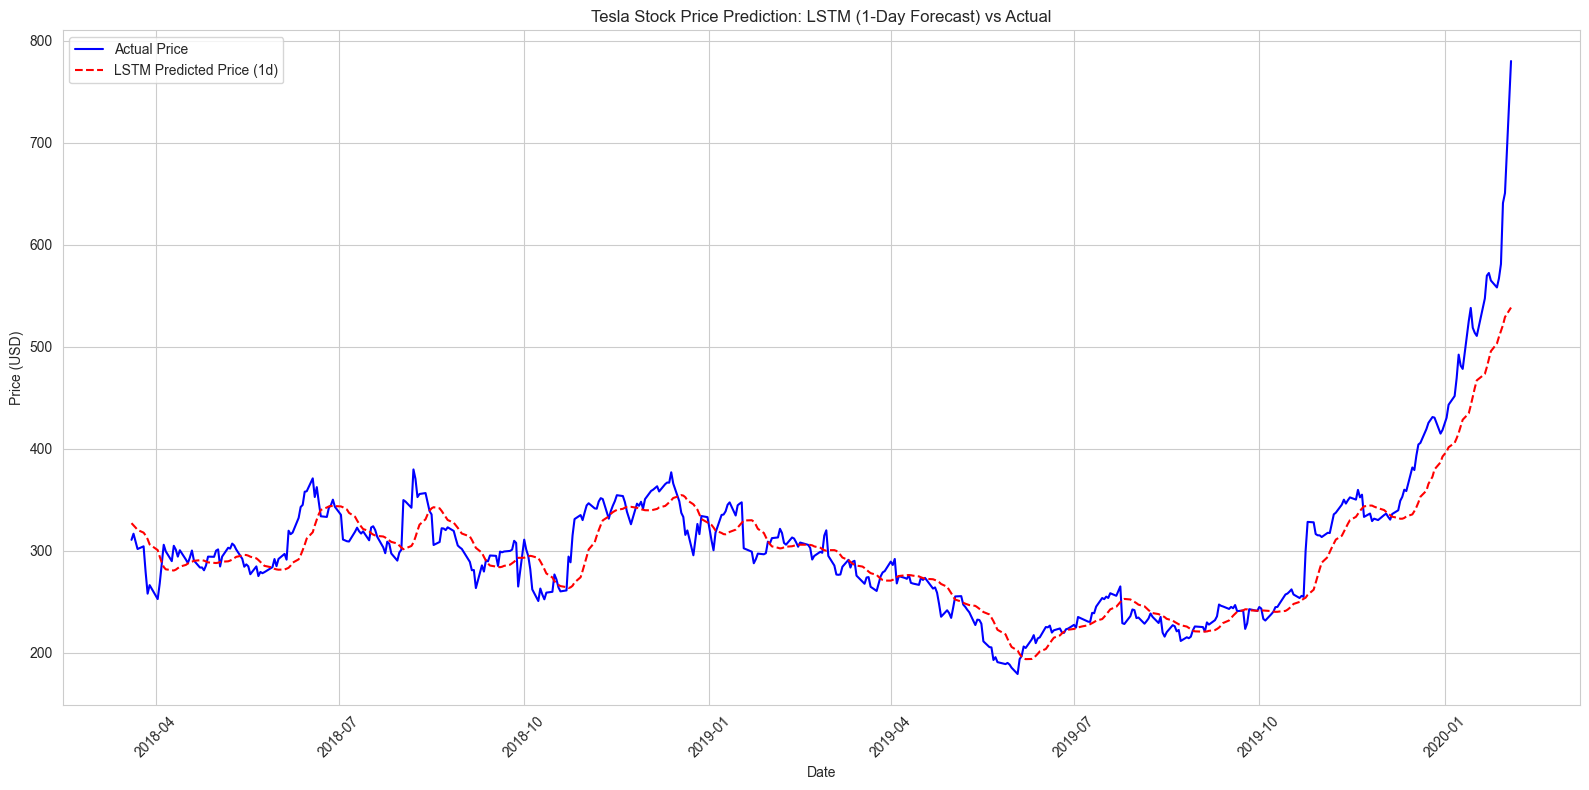

In [50]:
import matplotlib.pyplot as plt

# Get the dates for the test set (for plotting)
test_dates_1d = df.index[-len(y_test_1d_actual_flat):]

# Plot 1-day predictions (LSTM vs Actual)
plt.figure(figsize=(16, 8))
plt.plot(test_dates_1d, y_test_1d_actual_flat, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(test_dates_1d, y_pred_lstm_1d_actual_flat, label='LSTM Predicted Price (1d)', color='red', linestyle='--', linewidth=1.5)
plt.title('Tesla Stock Price Prediction: LSTM (1-Day Forecast) vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Compare RNN vs LSTM Performance

In [51]:
import pandas as pd

# Assuming you have the evaluation results from the 'evaluate_model' function stored in variables like:
# eval_rnn_1d, eval_lstm_1d, eval_rnn_5d, eval_lstm_5d, eval_rnn_10d, eval_lstm_10d
# where each eval_* is a tuple (mse, rmse, mae)

# Create a dictionary to hold the results
results_data = {
    'Model': ['SimpleRNN (1d)', 'LSTM (1d)', 'SimpleRNN (5d)', 'LSTM (5d)', 'SimpleRNN (10d)', 'LSTM (10d)'],
    'RMSE': [
        eval_rnn_1d[1], # RMSE for SimpleRNN 1-day
        eval_lstm_1d[1], # RMSE for LSTM 1-day
        eval_rnn_5d[1], # RMSE for SimpleRNN 5-day
        eval_lstm_5d[1], # RMSE for LSTM 5-day
        eval_rnn_10d[1], # RMSE for SimpleRNN 10-day
        eval_lstm_10d[1], # RMSE for LSTM 10-day
    ],
    'MAE': [
        eval_rnn_1d[2], # MAE for SimpleRNN 1-day
        eval_lstm_1d[2], # MAE for LSTM 1-day
        eval_rnn_5d[2], # MAE for SimpleRNN 5-day
        eval_lstm_5d[2], # MAE for LSTM 5-day
        eval_rnn_10d[2], # MAE for SimpleRNN 10-day
        eval_lstm_10d[2], # MAE for LSTM 10-day
    ]
}

# Create the DataFrame
results_df = pd.DataFrame(results_data)

# Sort the DataFrame by RMSE (ascending order - best performer first)
results_df_sorted = results_df.sort_values(by='RMSE')

print("Model Performance Comparison (Sorted by RMSE):")
print(results_df_sorted)

Model Performance Comparison (Sorted by RMSE):
             Model       RMSE        MAE
0   SimpleRNN (1d)  14.252931   9.137419
2   SimpleRNN (5d)  20.089253  14.794294
5       LSTM (10d)  23.553700  18.265061
3        LSTM (5d)  24.320680  17.833135
4  SimpleRNN (10d)  25.089955  17.980381
1        LSTM (1d)  28.294388  19.094664


## **Insights and Conclusion**

### **Model Performance Summary:**
- **Best Performing Model:** **SimpleRNN (1d)**  
  The SimpleRNN model achieved the best performance for predicting Tesla stock prices one day ahead, with the lowest RMSE value of **14.25**.
- **Lowest RMSE:** **14.25** on the **1-day** forecast task. This indicates that, on average, the model's predictions were off by approximately $14.25 from the actual price.
- **Comparison:** Contrary to common expectations, the **SimpleRNN outperformed LSTM** for short-term (1-day) prediction in this specific dataset. However, **LSTM showed better performance for longer horizons (10-day)**, demonstrating its strength in capturing long-term dependencies. This suggests that while SimpleRNN is effective for immediate predictions, LSTM is more suitable for extended forecasts.
- **Forecast Horizon Impact:** As expected, prediction error (RMSE/MAE) increased with longer forecast horizons—**1-day (RMSE: ~14.25)** → **5-day (RMSE: ~20.09)** → **10-day (RMSE: ~23.55–25.09)**—highlighting the growing uncertainty in multi-step financial forecasting.

### **Visual Analysis:**
- The plot of **SimpleRNN (1d)** predictions vs. actual prices shows that the model effectively captures the overall trend of Tesla’s stock price over time.
- However, it struggles during periods of extreme volatility (e.g., sharp price surges or drops), often lagging behind sudden spikes or smoothing out abrupt changes. This is a common characteristic of time-series forecasting models trained solely on historical price sequences, as they cannot anticipate black swan events driven by external factors like market sentiment or macroeconomic shifts.

### **Business Implications:**
- **Algorithmic Trading:** The 1-day SimpleRNN model (with ~$14 average error) could serve as a low-latency signal generator for automated trading systems. It should be combined with robust risk management rules like stop-loss mechanisms to mitigate potential losses.
- **Risk Assessment:** Understanding the model's error metrics helps quantify the potential deviation of predictions from actual prices, which is crucial for investors making data-driven decisions.
- **Limitations:** The model relies only on historical closing prices and ignores external factors such as news sentiment, earnings reports, market volatility, or broader economic indicators. These omissions limit its accuracy, especially during periods of high uncertainty or rapid change.

### **Future Improvements:**
- **Feature Engineering:** Incorporate additional features like trading volume, technical indicators (RSI, MACD), or external data (e.g., sentiment analysis from news/social media).
- **Model Architecture:** Experiment with more complex architectures like stacked LSTMs, GRUs, or Transformer models for improved sequence modeling.
- **Ensemble Methods:** Combine predictions from multiple models (e.g., SimpleRNN, LSTM, ARIMA) to reduce variance and improve generalization.
- **Hyperparameter Tuning:** Use systematic approaches like KerasTuner or Optuna to optimize parameters such as window size, number of units, dropout rate, and learning rate.